In [ ]:
import os
import cv2
import numpy as np
import mediapipe as mp
from sklearn.preprocessing import MinMaxScaler
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers, callbacks
from tqdm import tqdm
from tqdm.keras import TqdmCallback
import joblib
import matplotlib.pyplot as plt
import tensorflowjs as tfjs

In [4]:
print(tf.__version__)

2.20.0


In [125]:
target_dir = 'push-up'

for dirname, _, filenames in os.walk(target_dir):
    for filename in filenames:
        print(os.path.join(dirname, filename))


push-up/push-up_38.mp4
push-up/push-up_10.mp4
push-up/push-up_1.mp4
push-up/push-up_11.mp4
push-up/push-up_39.mp4
push-up/push-up_13.mp4
push-up/push-up_3.mp4
push-up/push-up_12.mp4
push-up/push-up_2.mp4
push-up/push-up_6.mp4
push-up/push-up_16.mp4
push-up/.DS_Store
push-up/push-up_7.mp4
push-up/push-up_17.mp4
push-up/push-up_15.mp4
push-up/push-up_5.mp4
push-up/push-up_29.mp4
push-up/push-up_28.mp4
push-up/push-up_14.mp4
push-up/push-up_4.mp4
push-up/push-up_49.mp4
push-up/push-up_48.mp4
push-up/push-up_52.mp4
push-up/push-up_46.mp4
push-up/push-up_47.mp4
push-up/push-up_53.mp4
push-up/push-up_45.mp4
push-up/push-up_51.mp4
push-up/push-up_50.mp4
push-up/push-up_44.mp4
push-up/push-up_40.mp4
push-up/push-up_54.mp4
push-up/push-up_55.mp4
push-up/push-up_41.mp4
push-up/push-up_57.mp4
push-up/push-up_43.mp4
push-up/push-up_42.mp4
push-up/push-up_56.mp4
push-up/push-up_19.mp4
push-up/push-up_9.mp4
push-up/push-up_31.mp4
push-up/push-up_25.mp4
push-up/push-up_24.mp4
push-up/push-up_30.mp4
p

# Pose Setup

In [126]:
mp_pose = mp.solutions.pose
pose = mp_pose.Pose(static_image_mode=False, model_complexity=1, enable_segmentation=False)

I0000 00:00:1764844377.878288  205592 gl_context.cc:369] GL version: 2.1 (2.1 Metal - 89.3), renderer: Apple M4


# Feature Extraction & Keypoint

##### Function for extract keypoints from the video

In [127]:
def extract_keypoints(path):
    cap = cv2.VideoCapture(path)
    keypts_all = []

    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break
        img_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        res = pose.process(img_rgb)
        if res.pose_landmarks:
            keypts = np.array([[lm.x, lm.y, lm.z] for lm in res.pose_landmarks.landmark])
            keypts_all.append(keypts)
    cap.release()
    return np.array(keypts_all)

##### Calculate Angle

In [128]:
def calculate_angle(A, B, C):
    vba = A - B
    vbc = C - B

    dot_product = np.dot(vba,vbc)
    magnitude = np.linalg.norm(vba) * np.linalg.norm(vbc)
    cos_angle = dot_product / (magnitude + 1e-6)
    angle_rad = np.arccos(np.clip(cos_angle, -1.0, 1.0))
    return np.degrees(angle_rad)

##### Feature Extraction

In [129]:
def extract_features(keypts_seq):
    if len(keypts_seq) == 0:
        return np.zeros(30)
    
    required_indices = max(16, 26) 
    
    if len(keypts_seq[0]) < required_indices + 1:
        return np.zeros(30)
    
    left_elbow   = [calculate_angle(f[11], f[13], f[15]) for f in keypts_seq]
    right_elbow  = [calculate_angle(f[12], f[14], f[16]) for f in keypts_seq]
    left_shoulder  = [calculate_angle(f[13], f[11], f[23]) for f in keypts_seq]
    right_shoulder = [calculate_angle(f[14], f[12], f[24]) for f in keypts_seq]
    left_hip     = [calculate_angle(f[11], f[23], f[25]) for f in keypts_seq]
    right_hip    = [calculate_angle(f[12], f[24], f[26]) for f in keypts_seq]
        
    features = []
    angle_sequences = [left_elbow, right_elbow, left_shoulder, right_shoulder, left_hip, right_hip]
    
    for seq in angle_sequences:
        features.extend([np.mean(seq), np.std(seq), np.min(seq), np.max(seq), np.ptp(seq)])

    return np.array(features)

In [130]:
def extract_features_video(path):
    keypts_all = extract_keypoints(path)
    return extract_features(keypts_all)

# 1. Data Preparation

In [4]:
base_dir = "push-up" 
output_dir = "models/pushup-models" 
os.makedirs(output_dir, exist_ok=True)

In [132]:
print(f"Isi direktori {base_dir}: {os.listdir(base_dir)[:5]}...")

Isi direktori push-up: ['push-up_38.mp4', 'push-up_10.mp4', 'push-up_1.mp4', 'push-up_11.mp4', 'push-up_39.mp4']...


In [133]:
features = []
for vid in tqdm(os.listdir(base_dir)):
    if not (vid.lower().endswith(".mp4") or vid.lower().endswith(".mov")): continue
    video_path = os.path.join(base_dir, vid)    
    feat = extract_features_video(video_path) 
    if np.allclose(feat, 0): continue
    features.append(feat)

  0%|          | 0/58 [00:00<?, ?it/s]W0000 00:00:1764844377.945958  384230 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1764844377.954467  384231 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
100%|██████████| 58/58 [02:30<00:00,  2.60s/it]


In [134]:
x = np.vstack(features)
print(f"Feature sample: {x.shape[0]}")

Feature sample: 57


# 2. Normalization

In [135]:
scaler = MinMaxScaler()
x_scaled = scaler.fit_transform(x)
joblib.dump(scaler, os.path.join(output_dir, "pushup_scaler.pkl"))

['models/pushup-models/pushup_scaler.pkl']

# 3. Model Building

In [150]:
inputs = layers.Input(shape=(x_scaled.shape[1], ))
x = layers.GaussianNoise(0.02)(inputs)
x = layers.Dense(64, activation="relu", kernel_regularizer=regularizers.l2(1e-4))(x)
x = layers.Dense(32, activation="relu", kernel_regularizer=regularizers.l2(1e-4))(x)
x = layers.Dropout(0.1)(x)
x = layers.Dense(16, activation="relu", kernel_regularizer=regularizers.l2(1e-4))(x) # 
x = layers.Dense(32, activation="relu")(x)
x = layers.Dense(64, activation="relu")(x)
outputs = layers.Dense(x_scaled.shape[1], activation="linear")(x)

In [151]:
autoencoder = models.Model(inputs, outputs)
autoencoder.summary()

Model: "functional_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_7 (InputLayer)      │ (None, 30)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gaussian_noise_7                │ (None, 30)             │             0 │
│ (GaussianNoise)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_42 (Dense)                │ (None, 64)             │         1,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_43 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_44 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_45 (Dense)                │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_46 (Dense)                │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_47 (Dense)                │ (None, 30)             │         1,950 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,198 (35.93 KB)

 Trainable params: 9,198 (35.93 KB)

 Non-trainable params: 0 (0.00 B)

In [152]:
autoencoder.compile(optimizer=tf.keras.optimizers.Adam(1e-3), loss="mse")

# 4. Model Training

**- early_stopping** digunakan <br>
**- reduce_lr** digunakan untuk menurunkan learning rate secara otomatis ketika model sudah tidak membaik lagi.

In [153]:
early_stopping = callbacks.EarlyStopping(monitor="val_loss", patience=12, restore_best_weights=True, verbose=0)
reduce_lr = callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=6, min_lr=1e-6, verbose=0)

In [154]:
history = autoencoder.fit(x_scaled, x_scaled, epochs=200, batch_size=8, validation_split=0.2, callbacks=[early_stopping, reduce_lr], verbose=1)

Epoch 1/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.3571 - val_loss: 0.2607 - learning_rate: 0.0010
Epoch 2/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.2635 - val_loss: 0.1936 - learning_rate: 0.0010
Epoch 3/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.2030 - val_loss: 0.1402 - learning_rate: 0.0010
Epoch 4/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1616 - val_loss: 0.1053 - learning_rate: 0.0010
Epoch 5/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1245 - val_loss: 0.0828 - learning_rate: 0.0010
Epoch 6/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0951 - val_loss: 0.0676 - learning_rate: 0.0010
Epoch 7/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0846 - val_loss: 0.0575 - learning_rate: 0.0010
Epoch 8/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0758 - val_loss: 0.0542 - learning_rate: 0.0010
Epoch 9/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0659 - val_loss: 0.0524 - learning_rate: 0.0010
Epoch 10/200
6/6 ━━━━━━━━━━━━━━━━━━━

# 5. Plotting

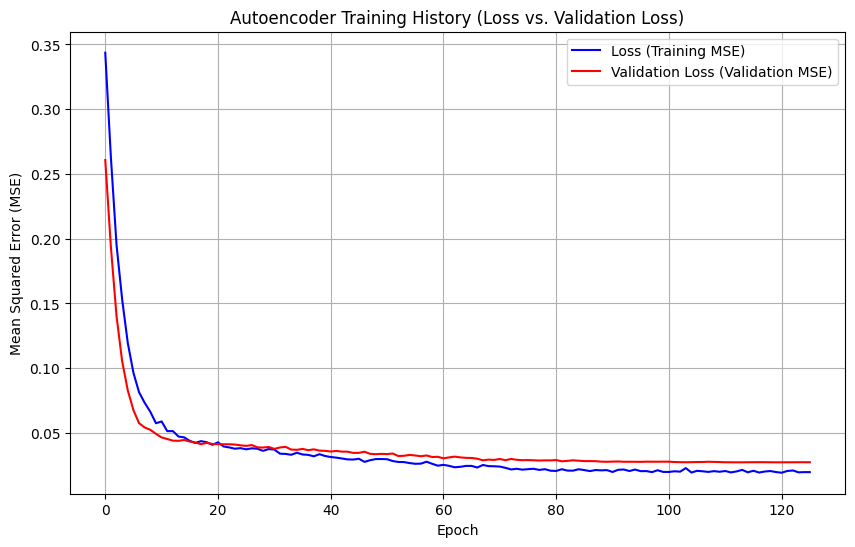

In [155]:
plt.figure(figsize=(10,6))
plt.plot(history.history['loss'], label='Loss (Training MSE)', color='blue')
plt.plot(history.history['val_loss'], label='Validation Loss (Validation MSE)', color='red')
plt.title('Autoencoder Training History (Loss vs. Validation Loss)')
plt.xlabel('Epoch')
plt.ylabel('Mean Squared Error (MSE)')
plt.legend()
plt.grid(True)
plt.show()

# 6. Save Model

In [156]:
path = os.path.join(output_dir, "pushup_autoencoder.keras")
autoencoder.save(path)

save tfjs karena kami berencana menggunakan react.js untuk frontend

In [157]:
tfjs_output = os.path.join(output_dir, "pushup_tfjs")
tfjs.converters.save_keras_model(autoencoder, tfjs_output)

failed to lookup keras version from the file,
    this is likely a weight only file


In [170]:
recon = autoencoder.predict(x_scaled, verbose=0)
train_mse_vals = np.mean(np.square(x_scaled - recon), axis=1)
np.save(os.path.join(output_dir, "pushup_train_mse_stats.npy"), train_mse_vals)

# 7. Testing

In [ ]:
test_video = "testingpushup2.mp4"

In [179]:
scaler_loaded = joblib.load(os.path.join(output_dir, "pushup_scaler.pkl"))
autoencoder_loaded = tf.keras.models.load_model(os.path.join(output_dir, "pushup_autoencoder.keras"))
train_mse_vals_loaded  = np.load(os.path.join(output_dir, "pushup_train_mse_stats.npy"))

In [180]:
feat = extract_features_video(test_video)

In [181]:
if np.allclose(feat, 0):
    score = 5.0  
else:
    feat_scaled = scaler_loaded.transform(feat.reshape(1, -1))
    reconstruction = autoencoder_loaded.predict(feat_scaled, verbose=0)
    mse = np.mean(np.square(feat_scaled - reconstruction))
    low, high = np.percentile(train_mse_vals_loaded, [5, 95])
    max_mse = high * 3 
    
    if mse <= low:
        score = 100
    elif mse >= max_mse:
        score = 5
    else:
        score = 100 - 95 * (mse - low) / (max_mse - low)
    
    score = float(np.clip(score, 5, 100))

print(f"Score for {test_video}: {score:.2f}/100")

Score for testingpushup2.mp4: 92.48/100
